In [18]:
from apiary import apiars

In [19]:
priv_key = "0202ea5001ba9d11e8fecb4a3a943fbaa4a1068821e35533bd2161e76d333811"

In [20]:
tokens_data = [
    ["ERC20", "0x81f8f0bb1cB2A06649E51913A151F0E7Ef6FA321", 1000],
    ["ERC20", "0xab814ce69E15F6B9660A3B184c0B0C97B9394A6b", 2000],
    ["ERC20", "0xA4fFdf3208F46898CE063e25c1C43056FA754739", 3000],
    ["ERC20", "0xD101dCC414F310268c37eEb4cD376CcFA507F571", 4000],
    ["ERC20", "0x761A3557184cbC07b7493da0661c41177b2f97fA", 5000],
    ["ERC20", "0xf4308b0263723b121056938c2172868E408079D0", 6000],
    ["ERC20", "0xF9Ca9523E5b5A42C3018C62B084Db8543478C400", 7000],
    ["ERC20", "0x9Ce115f0341ae5daBC8B477b74E83db2018A6f42", 8000],
    ["ERC20", "0xDd66781D0E9a08D4FBb5eC7BAc80B691BE27F21D", 9000],
    ["ERC20", "0x88b9f5c66342eBaf661b3E2836B807C8cb1B3195", 9999],
    ["ERC20", "0x1E762e1FAc176bbB341656035daf5601b1C69Be5", 10000],
    ["ERC721", "0xcaD88677CA87a7815728C72D74B4ff4982d54Fc1", 44],
]

In [21]:
# Filter ERC20 tokens
erc20_tokens = [(token[1], token[2]) for token in tokens_data if token[0] == "ERC20"]
erc20_tokens

[('0x81f8f0bb1cB2A06649E51913A151F0E7Ef6FA321', 1000),
 ('0xab814ce69E15F6B9660A3B184c0B0C97B9394A6b', 2000),
 ('0xA4fFdf3208F46898CE063e25c1C43056FA754739', 3000),
 ('0xD101dCC414F310268c37eEb4cD376CcFA507F571', 4000),
 ('0x761A3557184cbC07b7493da0661c41177b2f97fA', 5000),
 ('0xf4308b0263723b121056938c2172868E408079D0', 6000),
 ('0xF9Ca9523E5b5A42C3018C62B084Db8543478C400', 7000),
 ('0x9Ce115f0341ae5daBC8B477b74E83db2018A6f42', 8000),
 ('0xDd66781D0E9a08D4FBb5eC7BAc80B691BE27F21D', 9000),
 ('0x88b9f5c66342eBaf661b3E2836B807C8cb1B3195', 9999),
 ('0x1E762e1FAc176bbB341656035daf5601b1C69Be5', 10000)]

In [22]:
# Split token data into addresses and amounts for bundling
erc20_addresses = [token[0] for token in erc20_tokens]
erc20_amounts = [token[1] for token in erc20_tokens]

In [23]:
gas_bundle_array = []
gas_erc20_array = []

for i in range(3):  # range(len(erc20_addresses)):
    # Bundling transactions
    try:
        _, gas_bundle = apiars.bundle.make_buy_statement(
            erc20_addresses[: i + 1],
            erc20_amounts[: i + 1],
            [],
            [],
            "tmp",
            priv_key,
        )
        gas_bundle_array.append(gas_bundle)
    except RuntimeError as e:
        print(f"Error during bundling transaction: {e}")

    # Gas cost for individual ERC20 transactions
    gas_individual = 0
    for token_address, amount in erc20_tokens[: i + 1]:
        _, gas_local = apiars.erc20.make_buy_statement(
            token_address,
            amount,
            "tmp",
            priv_key,
        )
        gas_individual += gas_local
    gas_erc20_array.append(gas_individual)

In [24]:
gas_bundle_array

[608607, 718060, 830702]

In [25]:
gas_erc20_array

[480195, 936850, 1436516]

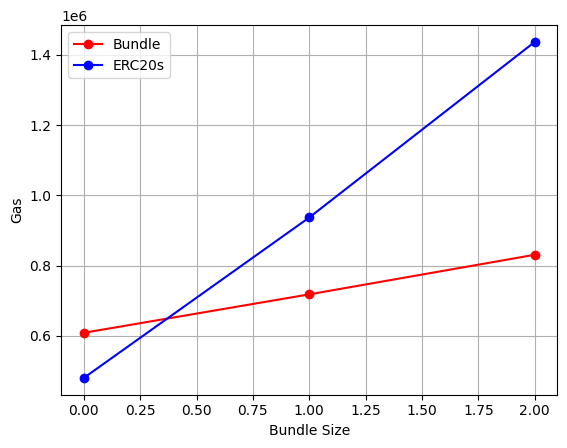

In [26]:
import matplotlib.pyplot as plt

# Example lists
list1 = [1, 3, 5, 7, 9]
list2 = [2, 4, 6, 8, 10]

# Plot the lists
plt.plot(gas_bundle_array, label="Bundle", color="red", marker="o")
plt.plot(gas_erc20_array, label="ERC20s", color="blue", marker="o")

# Add labels and title
plt.xlabel("Bundle Size")
plt.ylabel("Gas")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()